# **Import Libraries**

In [5]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RANDOM_STATE = 42
print("✅ Libraries loaded.")

✅ Libraries loaded.


# **Load Data**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df=pd.read_csv('/content/drive/MyDrive/Data Science/Datasets/Solar Energy.csv')

In [9]:
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())
display(df.dtypes)

Shape: 218,115 rows × 17 columns


,Data Through Date,Project ID,Interconnection Date,Utility,City/Town,County,Zip,Division,Substation,Circuit ID,Developer,Metering Method,Estimated PV System Size (kWdc),PV System Size (kWac),Estimated Annual PV Energy Production (kWh),Energy Storage System Size (kWac),Number of Projects
0,12/31/2023,SDG-66301,12/29/2023,Con Ed,Richmond Hill,Queens,"11,418.00",CENY-BK,Brownsville_2,9B05,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1
1,12/31/2023,SDG-66299,12/29/2023,Con Ed,Bronx,Bronx,"10,473.00",CENY-BX,Parkchester_2,5X67,Kamtech Solar Solutions,NM,6.74,5.76,7911,NaN,1
2,12/31/2023,SDG-66288,12/29/2023,Con Ed,Brooklyn,Kings,"11,225.00",CENY-BK,Bensonhurst_2,4B08,SUNCO,NM,3.05,2.61,3585,NaN,1
3,12/31/2023,SDG-66284,12/29/2023,Con Ed,Brooklyn,Kings,"11,236.00",CENY-BK,Bensonhurst_2,3037,Kamtech Solar Solutions,NM,5.62,4.80,6592,NaN,1
4,12/31/2023,SDG-66277,12/28/2023,Con Ed,Springfield Gardens,Queens,"11,413.00",CENY-Q,Jamaica,9112,Kamtech Solar Solutions,NM,6.05,5.17,7100,NaN,1


,0
Data Through Date,object
Project ID,object
Interconnection Date,object
Utility,object
City/Town,object
County,object
Zip,float64
Division,object
Substation,object
Circuit ID,object


# **Missing Values Overview**

In [11]:
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing %'     : (df.isnull().mean() * 100).round(2)
})
display(missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False))

,Missing Count,Missing %
Energy Storage System Size (kWac),214024,98.12
Division,85234,39.08
Substation,79944,36.65
Developer,10550,4.84
Metering Method,463,0.21
Zip,96,0.04
City/Town,58,0.03
Circuit ID,30,0.01
Project ID,3,0.00


# **Statistical Summary**

In [12]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Zip,"218,019.00","11,751.73",962.13,"10,001.00","11,220.00","11,717.00","12,018.00","14,905.00"
Estimated PV System Size (kWdc),"218,115.00",24.51,291.53,0.01,5.27,7.13,10.24,"43,470.00"
PV System Size (kWac),"218,115.00",19.07,211.42,0.01,4.50,6.09,8.75,"31,500.00"
Estimated Annual PV Energy Production (kWh),"218,115.00","28,768.28","342,204.18",14.00,"6,180.00","8,364.00","12,017.00","51,026,825.00"
Energy Storage System Size (kWac),"4,091.00",32.17,296.16,0.35,5.00,7.60,10.00,"5,000.00"
Number of Projects,"218,115.00",1.00,0.00,1.00,1.00,1.00,1.00,1.00


# **Target Variable Distribution**

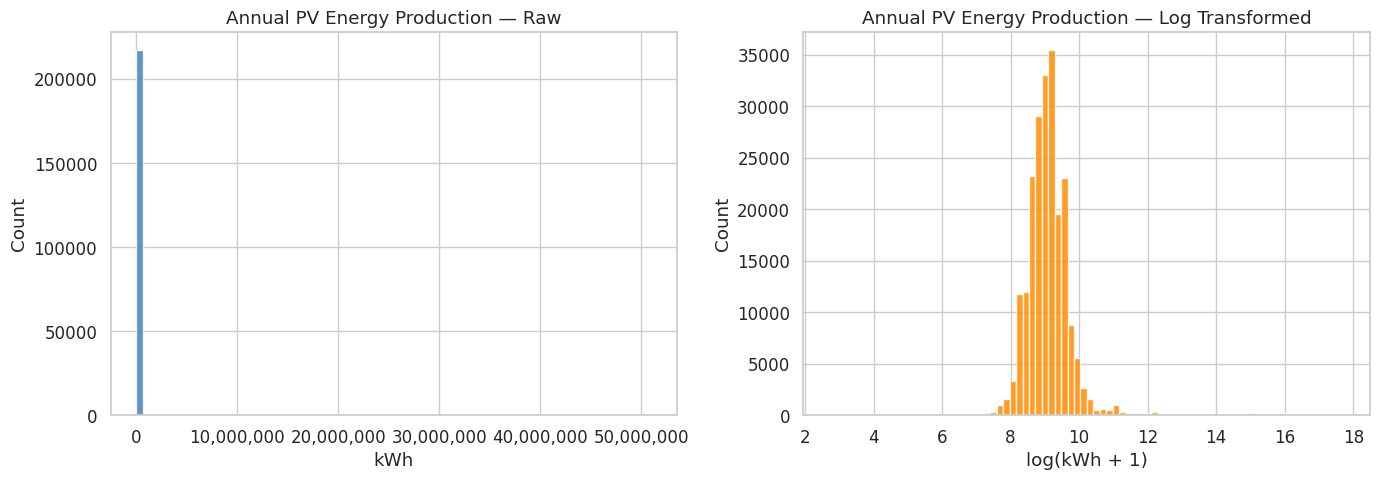

Skewness (raw)        : 42.36
Skewness (log-transformed): 3.10


In [13]:
TARGET = 'Estimated Annual PV Energy Production (kWh)'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[TARGET], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Annual PV Energy Production — Raw')
axes[0].set_xlabel('kWh')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

log_vals = np.log1p(df[TARGET])
axes[1].hist(log_vals, bins=80, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Annual PV Energy Production — Log Transformed')
axes[1].set_xlabel('log(kWh + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Skewness (raw)        : {df[TARGET].skew():.2f}")
print(f"Skewness (log-transformed): {log_vals.skew():.2f}")

# **Correlation Heatmap**

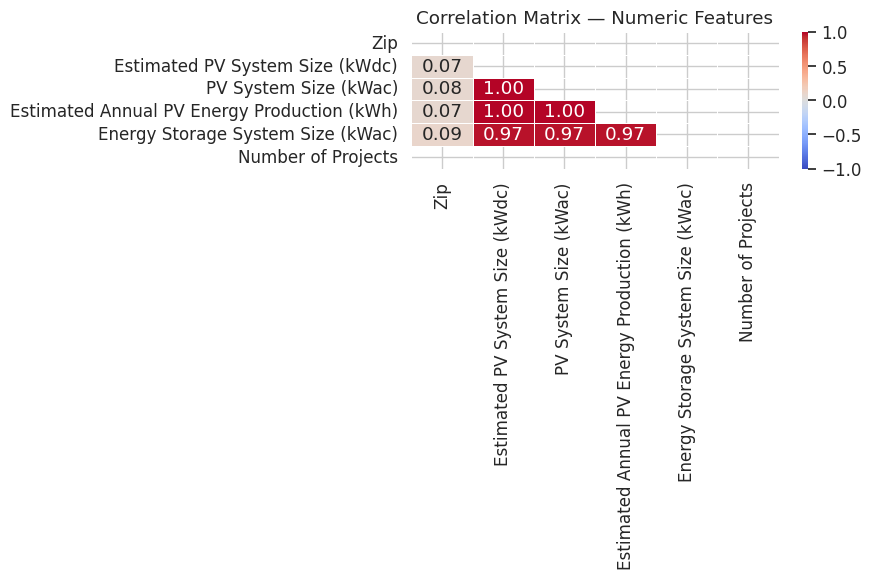

In [14]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

# **Top Developers by Project Count**

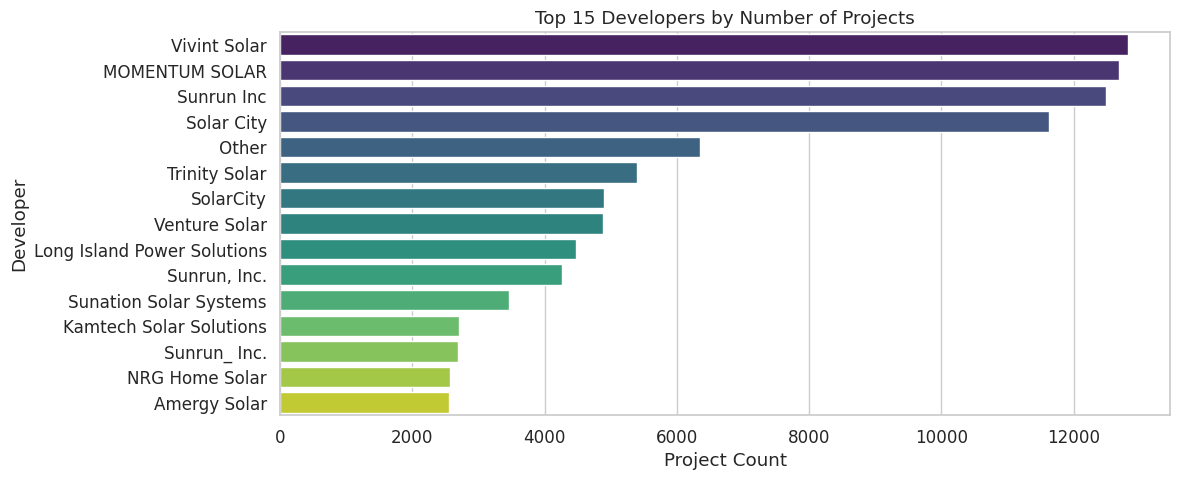

In [15]:
top_dev = df['Developer'].value_counts().head(15).reset_index()
top_dev.columns = ['Developer', 'Count']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_dev, x='Count', y='Developer', palette='viridis')
plt.title('Top 15 Developers by Number of Projects')
plt.xlabel('Project Count')
plt.tight_layout()
plt.show()

# **Average Production by Region**

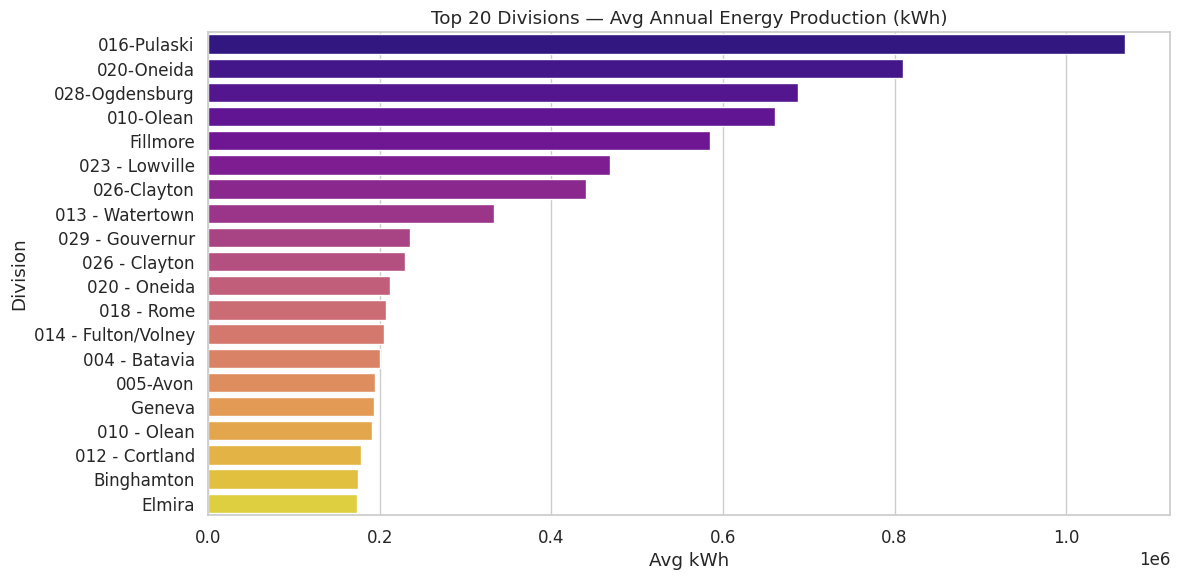

In [16]:
div_avg = (df.groupby('Division')[TARGET]
             .mean()
             .sort_values(ascending=False)
             .head(20)
             .reset_index())
div_avg.columns = ['Division', 'Avg_kWh']

plt.figure(figsize=(12, 6))
sns.barplot(data=div_avg, x='Avg_kWh', y='Division', palette='plasma')
plt.title('Top 20 Divisions — Avg Annual Energy Production (kWh)')
plt.xlabel('Avg kWh')
plt.tight_layout()
plt.show()

# **System Size vs. Production Scatter**

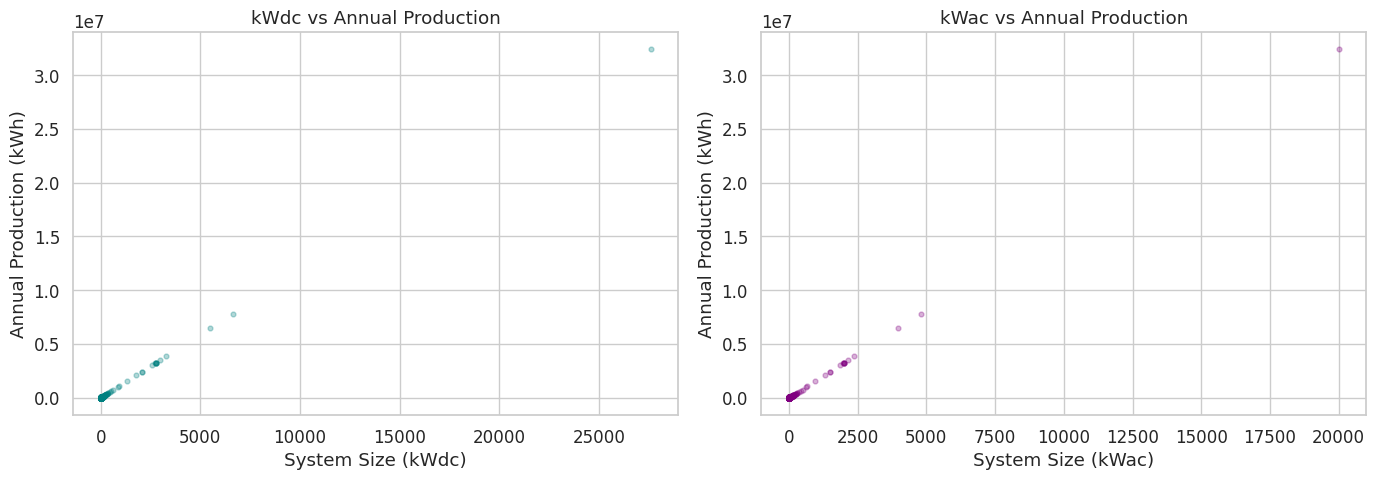

In [17]:
sample = df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['Estimated PV System Size (kWdc)'], sample[TARGET],
                alpha=0.3, color='teal', s=12)
axes[0].set_xlabel('System Size (kWdc)')
axes[0].set_ylabel('Annual Production (kWh)')
axes[0].set_title('kWdc vs Annual Production')

axes[1].scatter(sample['PV System Size (kWac)'], sample[TARGET],
                alpha=0.3, color='purple', s=12)
axes[1].set_xlabel('System Size (kWac)')
axes[1].set_ylabel('Annual Production (kWh)')
axes[1].set_title('kWac vs Annual Production')

plt.tight_layout()
plt.show()

# **Feature Engineering**

In [18]:
df2 = df.copy()

# Parse dates and extract year / month
df2['Interconnection Date'] = pd.to_datetime(df2['Interconnection Date'], errors='coerce')
df2['interconnection_year']  = df2['Interconnection Date'].dt.year
df2['interconnection_month'] = df2['Interconnection Date'].dt.month

# DC-to-AC ratio (efficiency indicator)
df2['kWdc_to_kWac_ratio'] = df2['Estimated PV System Size (kWdc)'] / (df2['PV System Size (kWac)'] + 1e-6)

# Binary flag: does the installation have energy storage?
df2['has_storage'] = df2['Energy Storage System Size (kWac)'].notna().astype(int)

# Log-transform the target
df2['log_target'] = np.log1p(df2[TARGET])

print("✅ New features added:")
print("   interconnection_year, interconnection_month, kWdc_to_kWac_ratio, has_storage, log_target")
print(f"   Dataset shape: {df2.shape}")

✅ New features added:
   interconnection_year, interconnection_month, kWdc_to_kWac_ratio, has_storage, log_target
   Dataset shape: (218115, 22)


# **Encode Categoricals & Prepare Final Dataset**

In [19]:
# ── Encode & Build Model-Ready Dataset ───────────────────────────────
FEATURES = [
    'Estimated PV System Size (kWdc)',
    'PV System Size (kWac)',
    'kWdc_to_kWac_ratio',
    'has_storage',
    'interconnection_year',
    'interconnection_month',
    'Developer',
    'Division',
    'County',
    'Metering Method',
    'Utility',
]

CAT_COLS = ['Developer', 'Division', 'County', 'Metering Method', 'Utility']

# Work on clean copy
df_model = df2[FEATURES + ['log_target', TARGET]].copy()
df_model = df_model[df_model[TARGET] > 0]
df_model = df_model.dropna(subset=['interconnection_year', 'interconnection_month'])

# Fill missing categoricals
for col in CAT_COLS:
    df_model[col] = df_model[col].fillna('Unknown')

# Label encode
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

print(f"✅ Model dataset ready: {df_model.shape[0]:,} rows × {len(FEATURES)} features")
display(df_model.head(3))

✅ Model dataset ready: 133,535 rows × 11 features


,Estimated PV System Size (kWdc),PV System Size (kWac),kWdc_to_kWac_ratio,has_storage,interconnection_year,interconnection_month,Developer,Division,County,Metering Method,Utility,log_target,Estimated Annual PV Energy Production (kWh)
0,6.05,5.17,1.17,0,"2,023.00",12.00,940,79,40,2,1,8.87,7100
1,6.74,5.76,1.17,0,"2,023.00",12.00,940,80,2,2,1,8.98,7911
2,3.05,2.61,1.17,0,"2,023.00",12.00,1504,79,23,2,1,8.18,3585


# **Train / Val / Test Split**

In [20]:
# ──  Train / Validation / Test Split (70 / 15 / 15) ──────────────────
X       = df_model[FEATURES].values
y_log   = df_model['log_target'].values
y_raw   = df_model[TARGET].values

X_train, X_temp, y_train_log, y_temp_log, y_train_raw, y_temp_raw = train_test_split(
    X, y_log, y_raw, test_size=0.30, random_state=RANDOM_STATE)

X_val, X_test, y_val_log, y_test_log, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp_log, y_temp_raw, test_size=0.50, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,} rows")
print(f"Val   : {X_val.shape[0]:,} rows")
print(f"Test  : {X_test.shape[0]:,} rows")

Train : 93,474 rows
Val   : 20,030 rows
Test  : 20,031 rows


# **Train & Compare 5 Models**

In [21]:
def evaluate_model(model, X_tr, y_tr_log, X_vl, y_vl_log, y_vl_raw, name):
    model.fit(X_tr, y_tr_log)
    pred_log = model.predict(X_vl)
    pred_raw = np.clip(np.expm1(pred_log), 0, None)

    return {
        'Model'    : name,
        'R² Score' : round(r2_score(y_vl_raw, pred_raw), 4),
        'MAE (kWh)': round(mean_absolute_error(y_vl_raw, pred_raw), 1),
        'RMSE (kWh)': round(np.sqrt(mean_squared_error(y_vl_raw, pred_raw)), 1),
        'MAPE (%)'  : round(mean_absolute_percentage_error(y_vl_raw, pred_raw) * 100, 2),
        '_model'    : model
    }

models_to_try = [
    (LinearRegression(),                                               'Linear Regression'),
    (Ridge(alpha=10, random_state=RANDOM_STATE),                       'Ridge Regression'),
    (DecisionTreeRegressor(max_depth=10, min_samples_leaf=20,
                           random_state=RANDOM_STATE),                 'Decision Tree'),
    (RandomForestRegressor(n_estimators=200, max_depth=20,
                           min_samples_leaf=10, n_jobs=-1,
                           random_state=RANDOM_STATE),                 'Random Forest'),
    (GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                               max_depth=6, subsample=0.8,
                               random_state=RANDOM_STATE),             'Gradient Boosting'),
]

all_results = []
for mdl, name in models_to_try:
    print(f"  Training {name} ...", end=' ', flush=True)
    res = evaluate_model(mdl, X_train, y_train_log, X_val, y_val_log, y_val_raw, name)
    all_results.append(res)
    print(f"R²={res['R² Score']}  MAE={res['MAE (kWh)']:,}  MAPE={res['MAPE (%)']}%")

results_df = pd.DataFrame(all_results).drop(columns=['_model'])
print("\n" + "="*60)
display(results_df.sort_values('R² Score', ascending=False).reset_index(drop=True))

  Training Linear Regression ... R²=-6.2882  MAE=26,543.3  MAPE=40.69%
  Training Ridge Regression ... R²=-19.9884  MAE=59,125.7  MAPE=42.56%
  Training Decision Tree ... R²=0.9977  MAE=635.8  MAPE=0.18%
  Training Random Forest ... R²=0.9994  MAE=300.2  MAPE=0.1%
  Training Gradient Boosting ... R²=1.0  MAE=17.6  MAPE=0.03%



,Model,R² Score,MAE (kWh),RMSE (kWh),MAPE (%)
0,Gradient Boosting,1.00,17.60,376.60,0.03
1,Random Forest,1.00,300.20,"7,148.30",0.10
2,Decision Tree,1.00,635.80,"14,564.50",0.18
3,Linear Regression,-6.29,"26,543.30","819,415.00",40.69
4,Ridge Regression,-19.99,"59,125.70","1,390,536.40",42.56


# **Model Comparison Bar Charts**

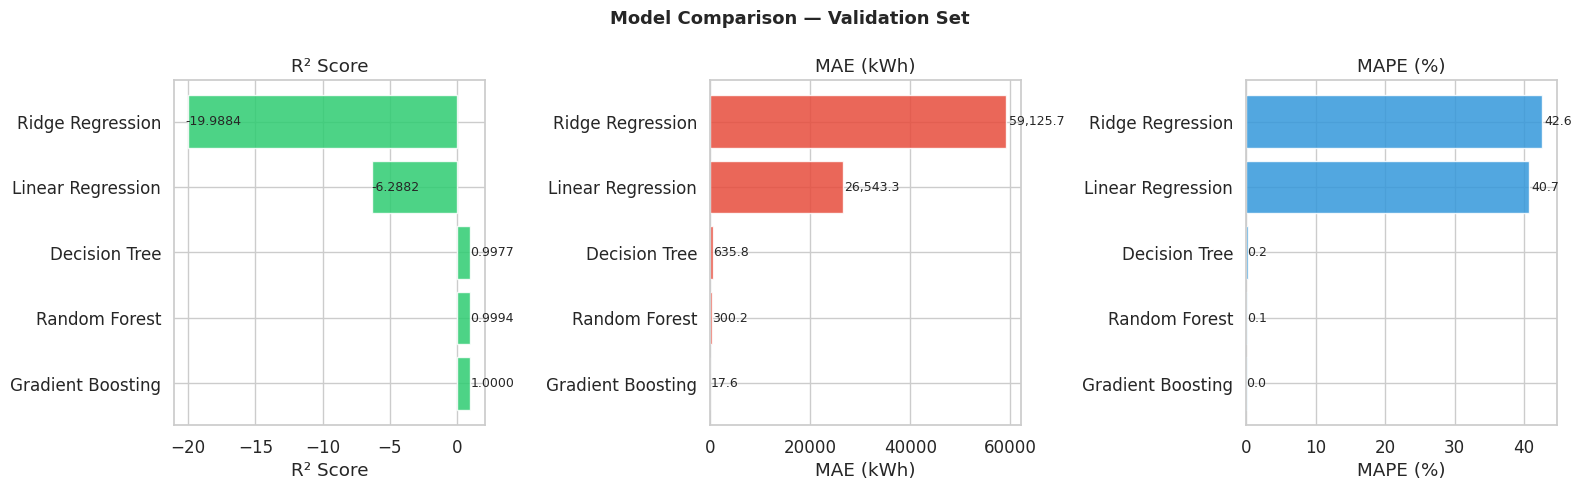

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, color, asc) in zip(axes, [
        ('R² Score',  '#2ecc71', False),
        ('MAE (kWh)', '#e74c3c', True),
        ('MAPE (%)',  '#3498db', True)]):

    sorted_df = results_df.sort_values(metric, ascending=asc)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.85)
    ax.set_title(f'{metric}')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}' if 'R²' in metric else f'{val:,.1f}',
                va='center', fontsize=9)

plt.suptitle('Model Comparison — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **Hyperparameter Tuning (Grid Search)**

In [26]:
param_grid = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [15, 20, None],
    'min_samples_leaf': [5, 10],
    'max_features'    : ['sqrt', 0.5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train_log)

print(f"\nBest parameters : {grid_search.best_params_}")
print(f"Best CV R²      : {grid_search.best_score_:.4f}")
best_rf = grid_search.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters : {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV R²      : 0.9994


# **Final Test Set Evaluation**

In [27]:
test_pred_raw = np.clip(np.expm1(best_rf.predict(X_test)), 0, None)

test_r2   = r2_score(y_test_raw, test_pred_raw)
test_mae  = mean_absolute_error(y_test_raw, test_pred_raw)
test_rmse = np.sqrt(mean_squared_error(y_test_raw, test_pred_raw))
test_mape = mean_absolute_percentage_error(y_test_raw, test_pred_raw) * 100

print("=" * 50)
print("  FINAL TEST SET RESULTS — Best Random Forest")
print("=" * 50)
print(f"  R² Score : {test_r2:.4f}")
print(f"  MAE      : {test_mae:,.2f} kWh")
print(f"  RMSE     : {test_rmse:,.2f} kWh")
print(f"  MAPE     : {test_mape:.2f} %")
print("=" * 50)

  FINAL TEST SET RESULTS — Best Random Forest
  R² Score : 0.9998
  MAE      : 187.37 kWh
  RMSE     : 3,945.44 kWh
  MAPE     : 0.08 %


# **Actual vs Predicted & Residual Plots**

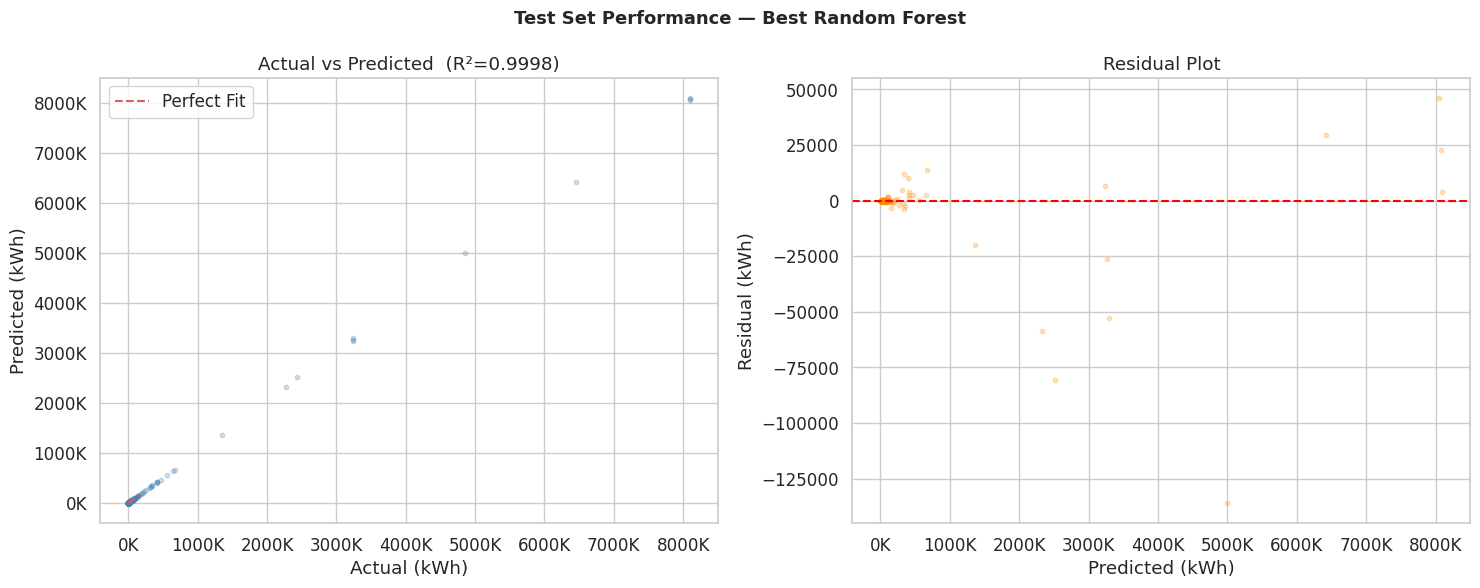

In [28]:
idx = np.random.choice(len(y_test_raw), size=3000, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted
axes[0].scatter(y_test_raw[idx], test_pred_raw[idx], alpha=0.25, s=10, color='steelblue')
lim_max = np.percentile(np.concatenate([y_test_raw, test_pred_raw]), 99)
axes[0].plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_xlabel('Actual (kWh)')
axes[0].set_ylabel('Predicted (kWh)')
axes[0].set_title(f'Actual vs Predicted  (R²={test_r2:.4f})')
axes[0].legend()
fmt = mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K')
axes[0].xaxis.set_major_formatter(fmt)
axes[0].yaxis.set_major_formatter(fmt)

# Residuals
residuals = y_test_raw - test_pred_raw
axes[1].scatter(test_pred_raw[idx], residuals[idx], alpha=0.25, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted (kWh)')
axes[1].set_ylabel('Residual (kWh)')
axes[1].set_title('Residual Plot')
axes[1].xaxis.set_major_formatter(fmt)

plt.suptitle('Test Set Performance — Best Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# **Feature Importance**

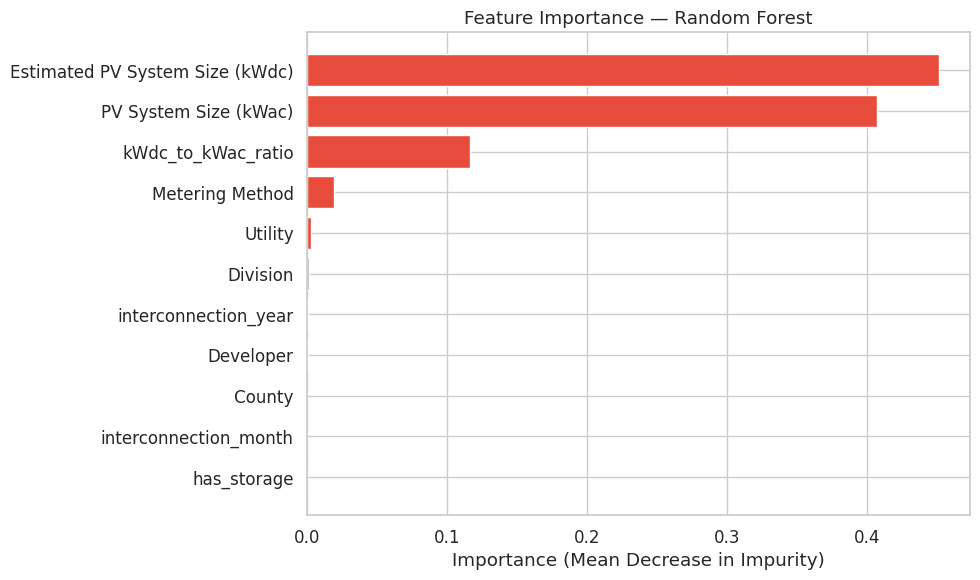


Top 5 Features:
                        Feature  Importance
Estimated PV System Size (kWdc)        0.45
          PV System Size (kWac)        0.41
             kWdc_to_kWac_ratio        0.12
                Metering Method        0.02
                        Utility        0.00


In [29]:
feat_imp = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

colors_fi = ['#e74c3c' if v > feat_imp['Importance'].median() else '#95a5a6'
             for v in feat_imp['Importance']]

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_fi)
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

print("\nTop 5 Features:")
print(feat_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

# **Permutation Importance**

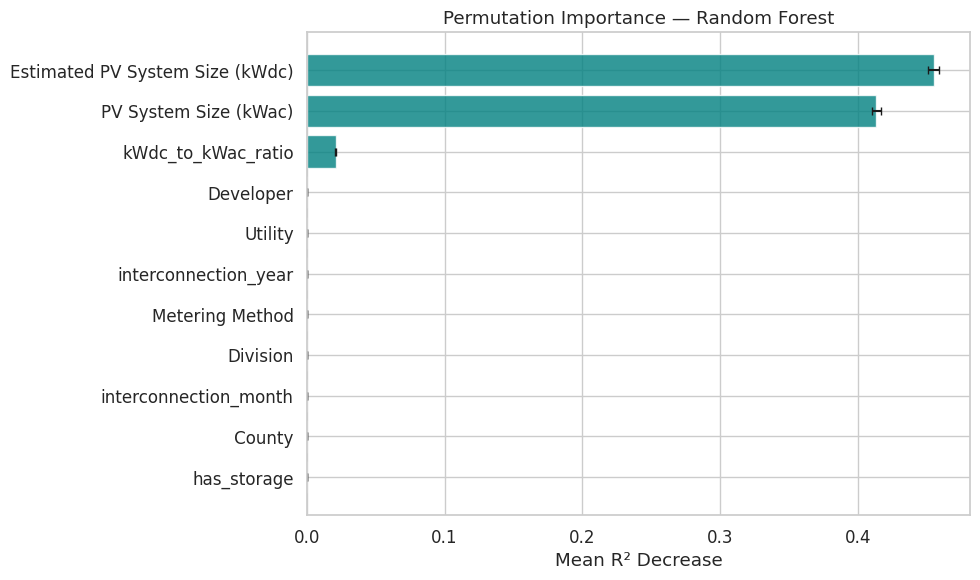

,Feature,Importance,Std
0,Estimated PV System Size (kWdc),0.46,0.00
1,PV System Size (kWac),0.41,0.00
2,kWdc_to_kWac_ratio,0.02,0.00
3,Developer,0.00,0.00
4,Utility,0.00,0.00
5,interconnection_year,0.00,0.00
6,Metering Method,0.00,0.00
7,Division,0.00,0.00
8,interconnection_month,0.00,0.00
9,County,0.00,0.00


In [30]:
perm = permutation_importance(best_rf, X_val, y_val_log,
                               n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)

perm_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': perm.importances_mean,
    'Std'       : perm.importances_std
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
         xerr=perm_df['Std'][::-1], color='teal', alpha=0.8, capsize=3)
plt.xlabel('Mean R² Decrease')
plt.title('Permutation Importance — Random Forest')
plt.tight_layout()
plt.show()

display(perm_df.reset_index(drop=True))

# **Cross-Validation**

5-Fold CV R² Scores:
  Fold 1: 0.9999
  Fold 2: 0.9992
  Fold 3: 0.9992
  Fold 4: 0.9997
  Fold 5: 0.9998

  Mean R² : 0.9996
  Std R²  : 0.0003


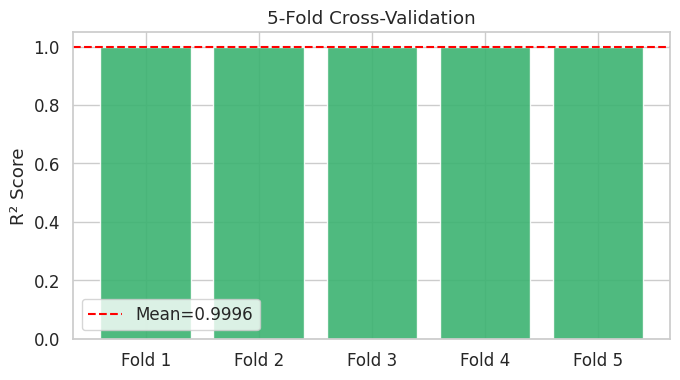

In [31]:
# ── 5-Fold Cross Validation ─────────────────────────────────────────
cv_scores = cross_val_score(best_rf, X_train, y_train_log,
                             cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                             scoring='r2', n_jobs=-1)

print("5-Fold CV R² Scores:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean R² : {cv_scores.mean():.4f}")
print(f"  Std R²  : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='mediumseagreen', edgecolor='white', alpha=0.9)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
plt.xticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)])
plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation')
plt.legend()
plt.tight_layout()
plt.show()

# **Production Prediction Function**

In [32]:
def predict_solar_production(developer, division, county, metering_method,
                              utility, pv_size_kwdc, pv_size_kwac,
                              has_storage_system, interconnection_year,
                              interconnection_month):
    """
    Predict annual solar energy production (kWh) for a new installation.

    Parameters
    ----------
    developer             : str   e.g. 'Vivint Solar'
    division              : str   e.g. 'East'
    county                : str   e.g. 'Suffolk'
    metering_method       : str   e.g. 'NM'
    utility               : str   e.g. 'LIPA'
    pv_size_kwdc          : float DC capacity in kW
    pv_size_kwac          : float AC capacity in kW
    has_storage_system    : int   1 = has battery, 0 = no battery
    interconnection_year  : int   e.g. 2025
    interconnection_month : int   1–12

    Returns
    -------
    float : Predicted annual energy production in kWh
    """
    def safe_encode(le, val):
        return list(le.classes_).index(val) if val in le.classes_ else 0

    row = [
        pv_size_kwdc,
        pv_size_kwac,
        pv_size_kwdc / (pv_size_kwac + 1e-6),
        has_storage_system,
        interconnection_year,
        interconnection_month,
        safe_encode(le_dict['Developer'],       developer),
        safe_encode(le_dict['Division'],        division),
        safe_encode(le_dict['County'],          county),
        safe_encode(le_dict['Metering Method'], metering_method),
        safe_encode(le_dict['Utility'],         utility),
    ]

    pred_log = best_rf.predict([row])[0]
    return float(np.expm1(pred_log))


# ── Example usage ─────────────────────────────────────────────────────────────
result = predict_solar_production(
    developer='Vivint Solar',
    division='East',
    county='Suffolk',
    metering_method='NM',
    utility='LIPA',
    pv_size_kwdc=10.0,
    pv_size_kwac=8.0,
    has_storage_system=0,
    interconnection_year=2025,
    interconnection_month=6
)
print(f"🔮 Predicted Annual Production : {result:,.0f} kWh")
print(f"   ≈ {result/1000:.1f} MWh per year")

🔮 Predicted Annual Production : 13,484 kWh
   ≈ 13.5 MWh per year


# **Importing file for use and reference**

In [34]:
# ── Dashboard Data for Power BI ───────────────────────────────────────

# 1. Predictions on the full model dataset
all_pred_log = best_rf.predict(X)
all_pred_raw = np.clip(np.expm1(all_pred_log), 0, None)

# 2. Rebuild readable dataframe (decode labels back)
dashboard_df = df_model[FEATURES + [TARGET]].copy()

# Decode categorical columns back to original strings
for col in CAT_COLS:
    dashboard_df[col] = le_dict[col].inverse_transform(dashboard_df[col].astype(int))

# Add predictions and error columns
dashboard_df['Predicted_kWh']   = all_pred_raw.round(0)
dashboard_df['Actual_kWh']      = dashboard_df[TARGET]
dashboard_df['Error_kWh']       = dashboard_df['Actual_kWh'] - dashboard_df['Predicted_kWh']
dashboard_df['AbsError_kWh']    = dashboard_df['Error_kWh'].abs()
dashboard_df['MAPE_pct']        = (dashboard_df['AbsError_kWh'] / (dashboard_df['Actual_kWh'] + 1e-6) * 100).round(2)
dashboard_df['Accuracy_pct']    = (100 - dashboard_df['MAPE_pct']).clip(0, 100).round(2)

# Feature importance table (separate export)
feat_imp_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Importance' : (best_rf.feature_importances_ * 100).round(2)
}).sort_values('Importance', ascending=False)

# Model summary table
model_summary = pd.DataFrame({
    'Metric': ['R² Score', 'MAE (kWh)', 'RMSE (kWh)', 'MAPE (%)', 'Test Samples'],
    'Value' : [
        round(test_r2, 4),
        round(test_mae, 2),
        round(test_rmse, 2),
        round(test_mape, 2),
        len(y_test_raw)
    ]
})

# Export all three CSVs
dashboard_df.to_csv('solar_dashboard_data.csv',  index=False)
feat_imp_df.to_csv('solar_feature_importance.csv', index=False)
model_summary.to_csv('solar_model_summary.csv',    index=False)

print(f"✅ Exported:")
print(f"   solar_dashboard_data.csv     — {len(dashboard_df):,} rows")
print(f"   solar_feature_importance.csv — {len(feat_imp_df)} features")
print(f"   solar_model_summary.csv      — model KPIs")
print(f"\nColumn list in dashboard data:")
print(list(dashboard_df.columns))

✅ Exported:
   solar_dashboard_data.csv     — 133,535 rows
   solar_feature_importance.csv — 11 features
   solar_model_summary.csv      — model KPIs

Column list in dashboard data:
['Estimated PV System Size (kWdc)', 'PV System Size (kWac)', 'kWdc_to_kWac_ratio', 'has_storage', 'interconnection_year', 'interconnection_month', 'Developer', 'Division', 'County', 'Metering Method', 'Utility', 'Estimated Annual PV Energy Production (kWh)', 'Predicted_kWh', 'Actual_kWh', 'Error_kWh', 'AbsError_kWh', 'MAPE_pct', 'Accuracy_pct']
